## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn import metrics

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)

In [2]:
KNN_data  = pd.read_csv('data_preprocess.csv')
KNN_data.head(5)

,age,job_level,tenure_years,salary_usd,salary_vs_market_pct,rto_mandate,days_in_office_required,commute_minutes,prefers_remote,flexibility_importance,...,department_Data,department_Engineering,department_Finance,department_HR,department_Marketing,department_Operations,department_Product,department_Sales,work_arrangement_onsite,work_arrangement_remote
0,26,0,5.5,70000,5.2,0,4,44,1,3,...,False,False,False,False,True,False,False,False,True,False
1,35,0,0.5,64000,-15.5,0,5,48,1,2,...,False,False,False,False,False,False,False,True,True,False
2,23,2,2.0,142000,-15.9,1,3,35,1,3,...,False,False,False,True,False,False,False,False,False,False
3,20,4,2.2,147000,2.6,0,5,16,0,5,...,False,False,False,False,False,False,False,True,True,False
4,40,2,6.0,141000,11.3,1,4,55,1,4,...,True,False,False,False,False,False,False,False,False,False


In [3]:
KNN_data.columns

Index(['age', 'job_level', 'tenure_years', 'salary_usd',
       'salary_vs_market_pct', 'rto_mandate', 'days_in_office_required',
       'commute_minutes', 'prefers_remote', 'flexibility_importance',
       'ai_tools_adoption', 'weekly_hours', 'after_hours_work',
       'burnout_score', 'manager_relationship_score', 'manager_1on1_per_month',
       'engagement_score', 'promotions_last_2y', 'career_growth_score',
       'recent_layoff_round', 'team_size', 'attrition', 'gender_Male',
       'gender_Other', 'department_Data', 'department_Engineering',
       'department_Finance', 'department_HR', 'department_Marketing',
       'department_Operations', 'department_Product', 'department_Sales',
       'work_arrangement_onsite', 'work_arrangement_remote'],
      dtype='object')

## choose X and Y

In [4]:
X = KNN_data[[
    'age',
    'job_level',
    'tenure_years',
    'salary_usd',
    'weekly_hours',
    'salary_vs_market_pct',
    'commute_minutes',
    'flexibility_importance',
    'rto_mandate',
    'days_in_office_required',
    'after_hours_work',
    'burnout_score',
    'manager_relationship_score',
    'engagement_score',
    'promotions_last_2y',
    'career_growth_score',
    'gender_Male',
    'gender_Other',
    'work_arrangement_onsite',
    'work_arrangement_remote'
]]

y = KNN_data['attrition']

## แบ่งข้อมูล Train/Test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## มันเปลี่ยนแต่ละ Feature ให้อยู่บนมาตรฐานเดียวกัน โดยใช้ StandardScaler

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## เลือก K

In [7]:
k_values = range(1, 21)
cv_scores = []

for k in k_values:

    knn_model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        knn_model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    cv_scores.append(scores.mean())

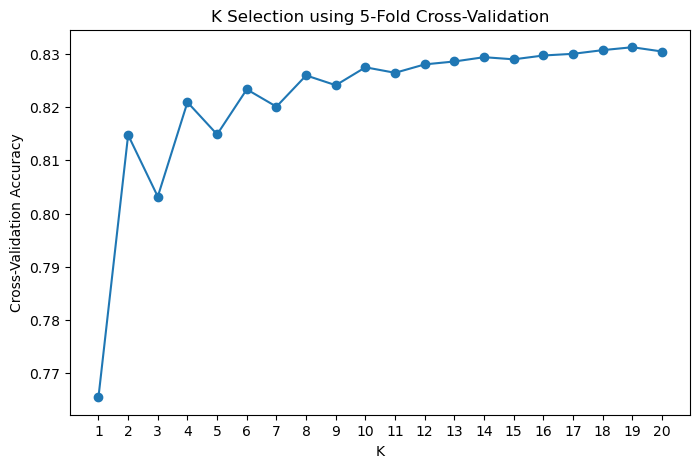

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, cv_scores, marker='o')

plt.xlabel("K")
plt.ylabel("Cross-Validation Accuracy")
plt.title("K Selection using 5-Fold Cross-Validation")
plt.xticks(k_values)

plt.show()

In [9]:
best_k = k_values[np.argmax(cv_scores)]

print("Best K:", best_k)
print("Best CV Accuracy:", max(cv_scores))

Best K: 19
Best CV Accuracy: 0.8312278322357219


## สร้าง KNN ด้วย Best K

In [10]:
KNN_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

## Fit and Predict X_test

In [11]:
KNN_model.fit(X_train, y_train)
y_pred = KNN_model.predict(X_test)

## Evaluate

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8326427255985267


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.97      0.90      7102
           1       0.63      0.20      0.31      1586

    accuracy                           0.83      8688
   macro avg       0.74      0.59      0.61      8688
weighted avg       0.81      0.83      0.80      8688



## Confusion matrix

In [14]:
confusion_matrix_KNN = metrics.confusion_matrix(
    y_test,
    y_pred
)

confusion_matrix_KNN

array([[6912,  190],
       [1264,  322]])

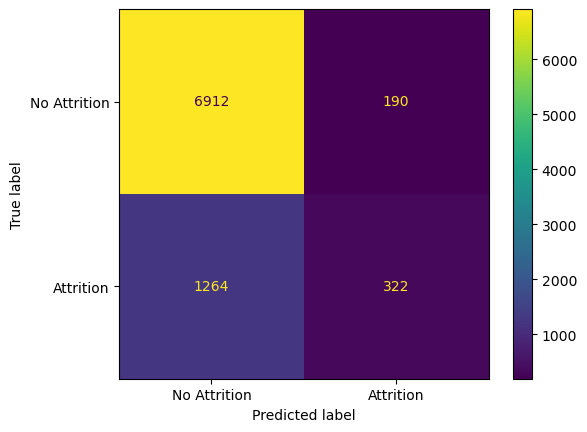

In [15]:
cm_display_KNN = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_KNN,
    display_labels=['No Attrition', 'Attrition']
)

cm_display_KNN.plot()
plt.show()

## บันทึกข้อมูลไปใช้ใน power BI

In [22]:
k_results = pd.DataFrame({
    'K': list(k_values),
    'CV_Accuracy': cv_scores
})

k_results.to_csv('knn_k_selection.csv',index=False)

In [23]:
evaluation_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score'
    ],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

evaluation_results.to_csv('knn_evaluation.csv',index=False)

In [27]:
cm = confusion_matrix(y_test, y_pred)

cm_results = pd.DataFrame({
    'Actual': [
        'No Attrition',
        'No Attrition',
        'Attrition',
        'Attrition'
    ],
    'Predicted': [
        'No Attrition',
        'Attrition',
        'No Attrition',
        'Attrition'
    ],
    'Count': [
        cm[0, 0],
        cm[0, 1],
        cm[1, 0],
        cm[1, 1]
    ]
})

cm_results.to_csv('knn_confusion_matrix.csv',index=False)

In [25]:
summary_results = pd.DataFrame({
    'Best K': [best_k],
    'CV Accuracy': [round(max(cv_scores) * 100, 2)],
    'Test Accuracy': [round(accuracy_score(y_test, y_pred) * 100, 2)]
})
summary_results.to_csv('knn_summary.csv',index=False)

In [26]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

performance_results = pd.DataFrame({
    'Class': [
        'No Attrition',
        'Attrition'
    ],
    'Precision': [
        report['0']['precision'],
        report['1']['precision']
    ],
    'Recall': [
        report['0']['recall'],
        report['1']['recall']
    ],
    'F1-score': [
        report['0']['f1-score'],
        report['1']['f1-score']
    ]
})

performance_results.to_csv('knn_performance.csv',index=False)